# **Вариант №18**

4. Для следующих 6-ти строчек из массива выполнить интерполяцию с помощью **второй** интерполяционной формулы Ньютона (```h = 0.1```), построить график.

Подключение библиотек

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

Получение данных из файла. Заносим в переменную `headers` заголовки столбцов, а в `values` соответственно значения.

In [68]:
clear_data = np.loadtxt(
    "18_Архангельск.csv", delimiter=",", dtype=str, encoding="utf-8-sig"
)

headers = clear_data[0]
values = clear_data[1:].astype(float)

headers

array(['Год', 'янв', 'фев', 'мар', 'апр', 'май', 'июн', 'июл', 'авг',
       'сен', 'окт', 'ноя', 'дек', 'средняя'], dtype='<U7')

Функция для отбора данных из таблицы данных.

Нам нужно взять информацию из столбцов, где нет значения «999.9». Поэтому мы сделаем так, чтобы строки с этим значением не учитывались.

In [69]:
def clear_cols(
    array: np.ndarray, col: int | list[int] = None, error: float | int | list = 999.9
) -> list[float] | np.ndarray:
    if col is None:
        col = list(range(array.shape[1]))
    elif isinstance(col, int):
        col = [col]

    if isinstance(error, (float, int)):
        error = [error]

    mask = np.ones(len(array), dtype=bool)
    for c in col:
        for err in error:
            mask &= array[:, c] != err

    result = array[mask][:, col].T

    if len(col) == 1:
        return result[0]
    else:
        return result

### **2-я интерполяционная формула Ньютона (назад)**
$$q = \frac{x - x_n}{n} < 0$$
$$N_{n}^{II}(x) = y_n + q \Delta y_{n-1} + \frac{q(q+1)}{2!} \Delta^2 y_{n-2} + \dots + \frac{q(q+1)\dots(q+n-1)}{n!} \Delta^n y_0$$

In [70]:
def coef(
    x_data: list[float] | np.ndarray,
    y_data: list[float] | np.ndarray,
    N: int = None,
):
    n = len(x_data)
    if N is None:
        N = n - 1
        
    A = np.zeros((N+1, N+1))
    B = np.zeros((N+1, 1))
    
    def sum_x(data: list | np.ndarray, degree: int):
        if degree == 0:
            return len(data)
        result = 0
        for k in range(len(data)):
            result += data[k]**degree
        return result
    
    def sum_y(x_data: list | np.ndarray, y_data: list | np.ndarray, degree: int):
        result = 0
        for k in range(len(y_data)):
            result += y_data[k] * x_data[k]**degree
        return result
    
    for i in range(N+1):
        for j in range(N+1):
            A[i, j] = sum_x(x_data, i+j)
            
    for i in range(N+1):
        B[i, 0] = sum_y(x_data, y_data, i)
    
    return np.linalg.solve(A, B)

def approximation_degree(
    x: float,
    x_data: list[float] | np.ndarray,
    y_data: list[float] | np.ndarray,
    N: int = None,
):
    c = coef(x_data, y_data, N)
    
    result = 0
    for i in range(len(c)):
        result += c[i] * x**i
    return result

Получаем очищенные данные из необходимых столбцов. Пусть это будет *год* и *январь*.

In [71]:
cols = (0, 1)

x_data, y_data = clear_cols(values, cols)

start = 0
end = start + 6

y_data, x_data = y_data[start:end], x_data[start:end]

print(f"{x_data=}")
print(f"{y_data=}")

x_data=array([1814., 1815., 1816., 1817., 1818., 1819.])
y_data=array([-24.6, -11.7,  -8.2,  -8.7, -10.1,  -8.3])


Построение графика

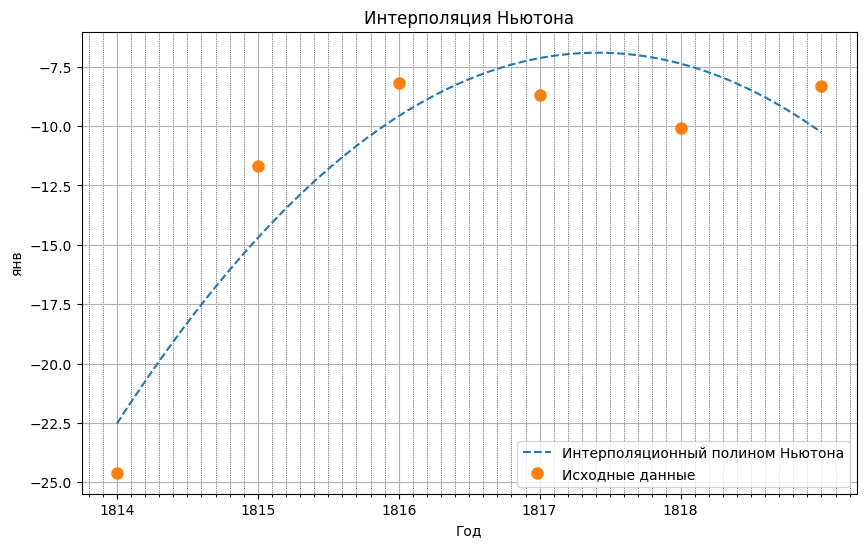

[-24.6 -11.7  -8.2  -8.7 -10.1  -8.3]


In [72]:
x_smooth = np.linspace(min(x_data), max(x_data), 100)
y_smooth = [approximation_degree(x, x_data, y_data, 5) for x in x_smooth]

plt.figure(figsize=(10, 6))
ax = plt.gca()
ax.xaxis.set_minor_locator(MultipleLocator(0.1))
plt.grid(True, which="minor", linestyle=":", linewidth=0.5, color="black")

plt.plot(x_smooth, y_smooth, "--", label="Интерполяционный полином Ньютона")
plt.plot(x_data, y_data, "o", label="Исходные данные", markersize=8)
plt.xticks(np.arange(x_data[0], x_data[-1], 1))

plt.xlabel(headers[cols[0]])
plt.ylabel(headers[cols[1]])
plt.title("Интерполяция Ньютона")
plt.legend()
plt.grid(True)
plt.show()
print(y_data)